# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

> **Status:** completed and re-run end-to-end in 2026. The first draft one-hot encoded *numeric* columns (e.g. `lead_time_0` … `lead_time_443` as separate dummies), relied on variables defined out of order, and left the tree, comparison and recommendation sections empty. This version fixes those issues.

## Importing libraries and data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 1

In [2]:
df = pd.read_csv('data/INNHotelsGroup.csv')
print(df.shape)
df.head()

(36275, 19)


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## Data overview

In [3]:
df.info()
print('\nMissing values:', df.isnull().sum().sum())
print('Duplicate Booking_IDs:', df['Booking_ID'].duplicated().sum())
print('Rows identical apart from Booking_ID:', df.drop(columns='Booking_ID').duplicated().sum())
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  str    
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  str    
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  str    
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date              

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


**Observations**
- 36,275 bookings, 19 columns, no missing values.
- About 10,000 rows are identical apart from the booking ID. These are separate bookings with the same attributes (e.g. group bookings), so they are kept.
- 545 bookings have a room price of 0 (mostly the *Complementary* segment) and 139 have 0 adults. These are valid edge cases, not errors.

## Exploratory Data Analysis

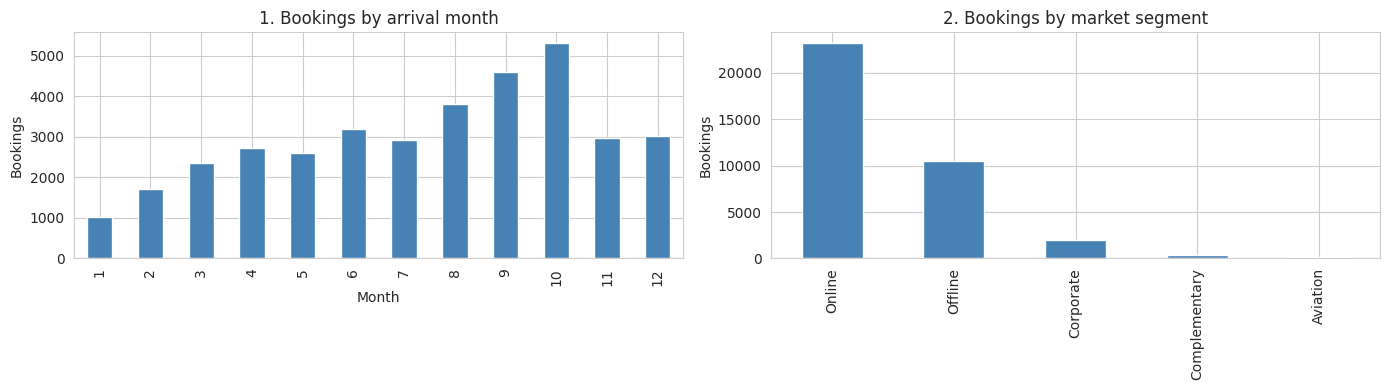

Busiest months: {10: 5317, 9: 4611, 8: 3813}
Segment share: {'Online': 0.64, 'Offline': 0.29, 'Corporate': 0.056, 'Complementary': 0.011, 'Aviation': 0.003}


In [4]:
df['canceled'] = (df['booking_status'] == 'Canceled').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['arrival_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set(title='1. Bookings by arrival month', xlabel='Month', ylabel='Bookings')
df['market_segment_type'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set(title='2. Bookings by market segment', xlabel='', ylabel='Bookings')
plt.tight_layout(); plt.show()

print('Busiest months:', df['arrival_month'].value_counts().head(3).to_dict())
print('Segment share:', df['market_segment_type'].value_counts(normalize=True).round(3).to_dict())

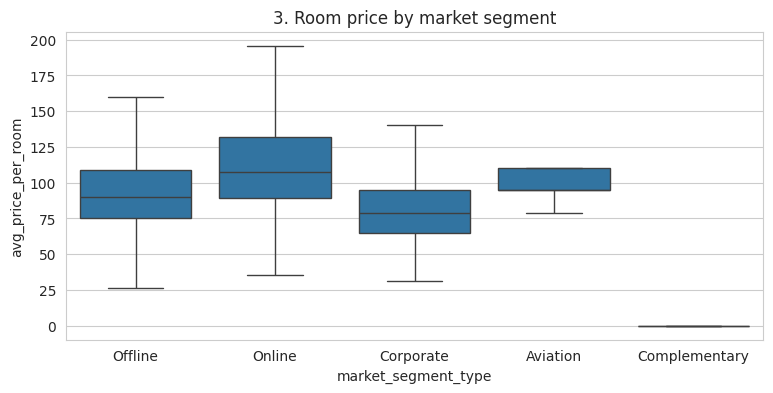

market_segment_type
Aviation          95.0
Complementary      0.0
Corporate         79.0
Offline           90.0
Online           107.1
Name: avg_price_per_room, dtype: float64


In [5]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x='market_segment_type', y='avg_price_per_room', showfliers=False)
plt.title('3. Room price by market segment'); plt.show()
print(df.groupby('market_segment_type')['avg_price_per_room'].median().round(1))

4. Share of bookings canceled: 32.8%
5. Cancellation rate of repeat guests: 1.7%  (new guests: 33.6%)


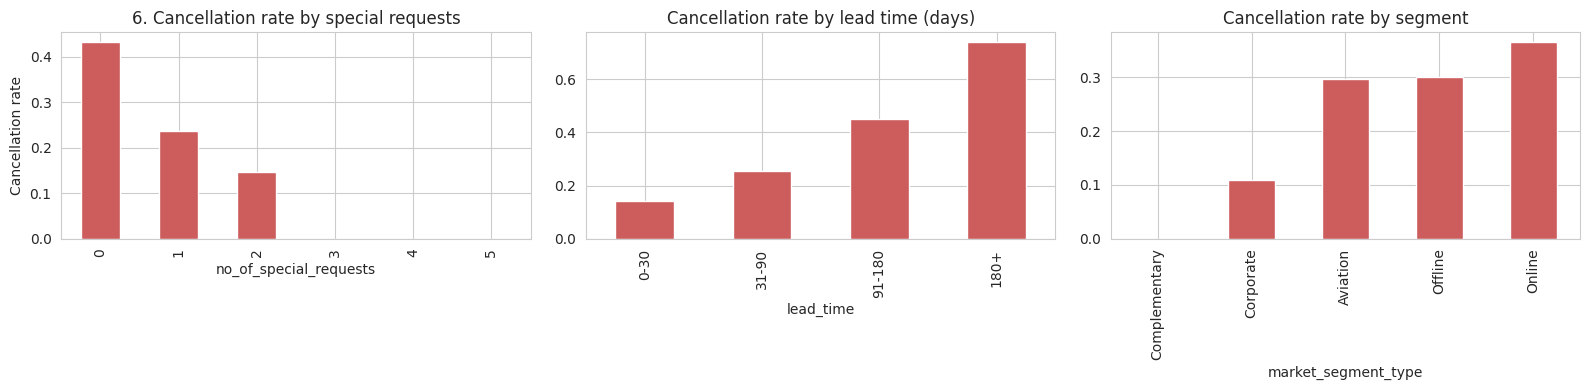

In [6]:
print(f"4. Share of bookings canceled: {df['canceled'].mean():.1%}")
print(f"5. Cancellation rate of repeat guests: {df.loc[df['repeated_guest']==1, 'canceled'].mean():.1%}"
      f"  (new guests: {df.loc[df['repeated_guest']==0, 'canceled'].mean():.1%})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df.groupby('no_of_special_requests')['canceled'].mean().plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set(title='6. Cancellation rate by special requests', ylabel='Cancellation rate')
lead_bins = pd.cut(df['lead_time'], [-1, 30, 90, 180, 1000], labels=['0-30', '31-90', '91-180', '180+'])
df.groupby(lead_bins)['canceled'].mean().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set(title='Cancellation rate by lead time (days)')
df.groupby('market_segment_type')['canceled'].mean().sort_values().plot(kind='bar', ax=axes[2], color='indianred')
axes[2].set(title='Cancellation rate by segment')
plt.tight_layout(); plt.show()

**EDA answers**
1. **Busiest months:** October, then September and August.
2. **Market segment:** 64% of bookings are Online, 29% Offline.
3. **Price by segment:** Online rooms are the most expensive (median ≈ €107), Corporate ≈ €79, Complementary €0. Prices are *not* even across segments.
4. **Cancellations:** 32.8% of all bookings are canceled.
5. **Repeat guests:** only 1.7% cancel, vs about 33% of new guests.
6. **Special requests:** strongly linked to lower cancellation: 43% with none, 24% with one, 15% with two, 0% with three or more.

**Lead time** is the clearest driver: 14% of bookings made within 30 days are canceled, vs 74% of bookings made more than 180 days ahead.

## Data preprocessing

In [7]:
X = df.drop(columns=['Booking_ID', 'booking_status', 'canceled'])
y = df['canceled']

# One-hot encode only the categorical columns; numeric columns stay numeric
X['arrival_year'] = X['arrival_year'] - 2017   # 0 = 2017, 1 = 2018 (keeps the intercept well-scaled)
X = pd.get_dummies(X, columns=['type_of_meal_plan', 'room_type_reserved', 'market_segment_type'],
                   drop_first=True, dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Cancel rate train/test:', round(y_train.mean(), 3), round(y_test.mean(), 3))

Train: (25392, 27)  Test: (10883, 27)
Cancel rate train/test: 0.328 0.328


## Metric choice
- **False negative** (we predict *not canceled*, the guest cancels): the room stays empty and revenue is lost.
- **False positive** (we predict *canceled*, the guest arrives): risk of overbooking and a bad guest experience.

Both errors cost money, so the main metric is **F1**. Recall is also reported.

In [8]:
def scores(model_name, y_true, y_pred, y_prob=None):
    return pd.Series({'Accuracy': accuracy_score(y_true, y_pred), 'Recall': recall_score(y_true, y_pred),
                      'Precision': precision_score(y_true, y_pred), 'F1': f1_score(y_true, y_pred),
                      'ROC-AUC': roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan},
                     name=model_name).round(3)

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=np.array([[f'{v}\n{v/cm.sum():.1%}' for v in r] for r in cm]), fmt='', cmap='Blues', cbar=False)
    plt.xlabel('Predicted (1 = canceled)'); plt.ylabel('Actual'); plt.title(title); plt.show()

## Logistic regression (statsmodels)

### Multicollinearity check (VIF)

In [9]:
def vif_table(data):
    data = sm.add_constant(data)
    return pd.Series([variance_inflation_factor(data.values, i) for i in range(data.shape[1])],
                     index=data.columns).drop('const').sort_values(ascending=False)

vif = vif_table(X_train)
vif.head(10).round(2)

market_segment_type_Online              69.47
market_segment_type_Offline             62.51
market_segment_type_Corporate           16.63
market_segment_type_Complementary        4.35
avg_price_per_room                       2.03
no_of_children                           2.01
room_type_reserved_Room_Type 6           1.99
repeated_guest                           1.75
no_of_previous_bookings_not_canceled     1.57
arrival_year                             1.43
dtype: float64

In [10]:
# Drop the market-segment dummies with VIF > 5 one at a time, starting with the highest
X_train_lr, X_test_lr = X_train.copy(), X_test.copy()
while True:
    v = vif_table(X_train_lr)
    if v.iloc[0] <= 5:
        break
    print(f'Dropping {v.index[0]} (VIF {v.iloc[0]:.1f})')
    X_train_lr, X_test_lr = X_train_lr.drop(columns=v.index[0]), X_test_lr.drop(columns=v.index[0])
print('Max VIF now:', round(vif_table(X_train_lr).max(), 2))

Dropping market_segment_type_Online (VIF 69.5)


Max VIF now: 2.03


### Remove insignificant variables (p > 0.05)

In [11]:
cols = list(X_train_lr.columns)
while True:
    model = sm.Logit(y_train, sm.add_constant(X_train_lr[cols])).fit(disp=0)
    p = model.pvalues.drop('const')
    if p.max() <= 0.05:
        break
    cols.remove(p.idxmax())
lg = model
print(f'{len(cols)} significant predictors kept')
print(lg.summary2().tables[1][['Coef.', 'P>|z|']].round(3))

/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.11/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


19 significant predictors kept
                                Coef.  P>|z|
const                          -3.048  0.000
no_of_weekend_nights            0.150  0.000
no_of_week_nights               0.036  0.003
required_car_parking_space     -1.615  0.000
lead_time                       0.016  0.000
arrival_year                    0.430  0.000
arrival_month                  -0.049  0.000
repeated_guest                 -3.075  0.000
no_of_previous_cancellations    0.289  0.000
avg_price_per_room              0.019  0.000
no_of_special_requests         -1.486  0.000
type_of_meal_plan_Meal Plan 2   0.167  0.013
type_of_meal_plan_Not Selected  0.210  0.000
room_type_reserved_Room_Type 2 -0.373  0.004
room_type_reserved_Room_Type 4 -0.268  0.000
room_type_reserved_Room_Type 5 -0.688  0.001
room_type_reserved_Room_Type 6 -0.742  0.000
room_type_reserved_Room_Type 7 -1.315  0.000
market_segment_type_Corporate  -0.871  0.000
market_segment_type_Offline    -1.772  0.000


*The convergence warnings come from early iterations that still include the Complementary segment, where no bookings are canceled (perfect separation). That dummy is removed by the loop, and the final model converges.*

### Interpreting the coefficients (odds ratios)

In [12]:
odds = pd.DataFrame({'Odds ratio': np.exp(lg.params), 'Change in odds (%)': (np.exp(lg.params) - 1) * 100}).drop('const')
odds.sort_values('Odds ratio').round(3)

,Odds ratio,Change in odds (%)
repeated_guest,0.046,-95.380
market_segment_type_Offline,0.170,-83.009
required_car_parking_space,0.199,-80.107
no_of_special_requests,0.226,-77.361
room_type_reserved_Room_Type 7,0.268,-73.153
market_segment_type_Corporate,0.419,-58.148
room_type_reserved_Room_Type 6,0.476,-52.378
room_type_reserved_Room_Type 5,0.503,-49.739
room_type_reserved_Room_Type 2,0.688,-31.163
room_type_reserved_Room_Type 4,0.765,-23.497


- **Each special request** cuts the odds of cancellation by about 77%.
- **Each extra day of lead time** raises the odds by about 1.6%, so 100 extra days roughly multiply the odds by 4–5.
- **Repeat guests (−95%), Offline bookings (−83%) and parking requests (−80%)** are linked to much lower odds. Each previous cancellation raises the odds by about 33%.
- **Higher room price** slightly raises the odds of cancellation (guests keep looking for a cheaper option).

### Choosing the classification threshold

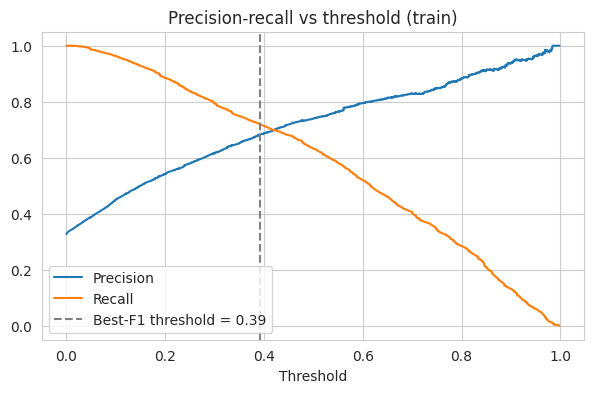

ROC-optimal (Youden) threshold: 0.33   Best-F1 threshold: 0.39


In [13]:
X_test_c = sm.add_constant(X_test_lr[cols])
X_train_c = sm.add_constant(X_train_lr[cols])
prob_train, prob_test = lg.predict(X_train_c), lg.predict(X_test_c)

fpr, tpr, roc_thr = roc_curve(y_train, prob_train)
youden_thr = roc_thr[np.argmax(tpr - fpr)]
prec, rec, pr_thr = precision_recall_curve(y_train, prob_train)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1])
f1_thr = pr_thr[np.argmax(f1s)]

plt.figure(figsize=(7, 4))
plt.plot(pr_thr, prec[:-1], label='Precision'); plt.plot(pr_thr, rec[:-1], label='Recall')
plt.axvline(f1_thr, ls='--', c='grey', label=f'Best-F1 threshold = {f1_thr:.2f}')
plt.xlabel('Threshold'); plt.legend(); plt.title('Precision-recall vs threshold (train)'); plt.show()
print(f'ROC-optimal (Youden) threshold: {youden_thr:.2f}   Best-F1 threshold: {f1_thr:.2f}')

In [14]:
lr_results = pd.concat([
    scores('LogReg (0.50)', y_test, (prob_test > 0.50).astype(int), prob_test),
    scores(f'LogReg ({f1_thr:.2f})', y_test, (prob_test > f1_thr).astype(int), prob_test)], axis=1).T
lr_results

,Accuracy,Recall,Precision,F1,ROC-AUC
LogReg (0.50),0.803,0.626,0.733,0.675,0.861
LogReg (0.39),0.794,0.715,0.675,0.694,0.861


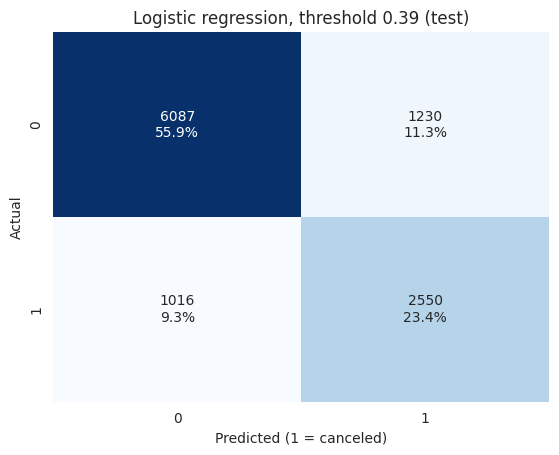

In [15]:
plot_cm(y_test, (prob_test > f1_thr).astype(int), f'Logistic regression, threshold {f1_thr:.2f} (test)')

## Decision tree

### Default tree

In [16]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
print('Train F1:', round(f1_score(y_train, dt.predict(X_train)), 3),
      ' Test F1:', round(f1_score(y_test, dt.predict(X_test)), 3), ' Depth:', dt.get_depth())

Train F1: 0.991  Test F1: 0.791  Depth: 38


The default tree grows to full depth and overfits (train F1 ≈ 0.99). It needs pruning.

### Pre-pruning (grid search)

In [17]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    {'max_depth': [4, 6, 8, 10, 12], 'max_leaf_nodes': [50, 100, 250, 500], 'min_samples_split': [10, 30, 50]},
    scoring='f1', cv=5, n_jobs=-1).fit(X_train, y_train)
dt_pre = grid.best_estimator_
print(grid.best_params_)
print('Train F1:', round(f1_score(y_train, dt_pre.predict(X_train)), 3),
      ' Test F1:', round(f1_score(y_test, dt_pre.predict(X_test)), 3))

{'max_depth': 12, 'max_leaf_nodes': 250, 'min_samples_split': 10}
Train F1: 0.825  Test F1: 0.795


### Post-pruning (cost-complexity)

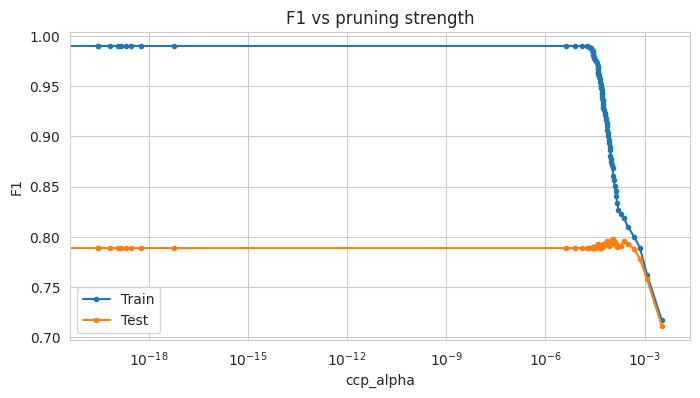

Chosen alpha: 0.000108  Leaves: 512


In [18]:
path = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced').cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[::20]   # sample the path to keep run time short
train_f1, test_f1, trees = [], [], []
for a in alphas:
    t = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced', ccp_alpha=a).fit(X_train, y_train)
    trees.append(t); train_f1.append(f1_score(y_train, t.predict(X_train))); test_f1.append(f1_score(y_test, t.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(alphas, train_f1, marker='.', label='Train'); plt.plot(alphas, test_f1, marker='.', label='Test')
plt.xscale('log'); plt.xlabel('ccp_alpha'); plt.ylabel('F1'); plt.legend(); plt.title('F1 vs pruning strength'); plt.show()

# NOTE: choosing alpha on the test set makes the test score slightly optimistic;
# a validation split or CV would be stricter.
dt_post = trees[int(np.argmax(test_f1))]
print('Chosen alpha:', round(dt_post.ccp_alpha, 6), ' Leaves:', dt_post.get_n_leaves())

In [19]:
dt_results = pd.concat([
    scores('Tree (default)', y_test, dt.predict(X_test), dt.predict_proba(X_test)[:, 1]),
    scores('Tree (pre-pruned)', y_test, dt_pre.predict(X_test), dt_pre.predict_proba(X_test)[:, 1]),
    scores('Tree (post-pruned)', y_test, dt_post.predict(X_test), dt_post.predict_proba(X_test)[:, 1])], axis=1).T
dt_results

,Accuracy,Recall,Precision,F1,ROC-AUC
Tree (default),0.863,0.793,0.790,0.791,0.847
Tree (pre-pruned),0.857,0.849,0.748,0.795,0.929
Tree (post-pruned),0.860,0.841,0.758,0.798,0.921


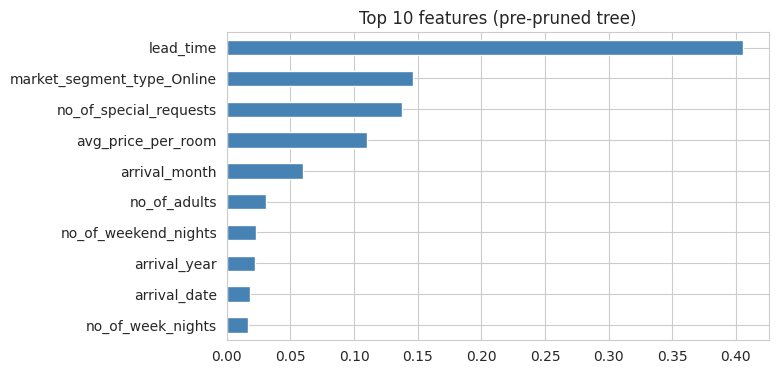

In [20]:
imp = pd.Series(dt_pre.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
imp.sort_values().plot(kind='barh', figsize=(7, 4), color='steelblue', title='Top 10 features (pre-pruned tree)'); plt.show()

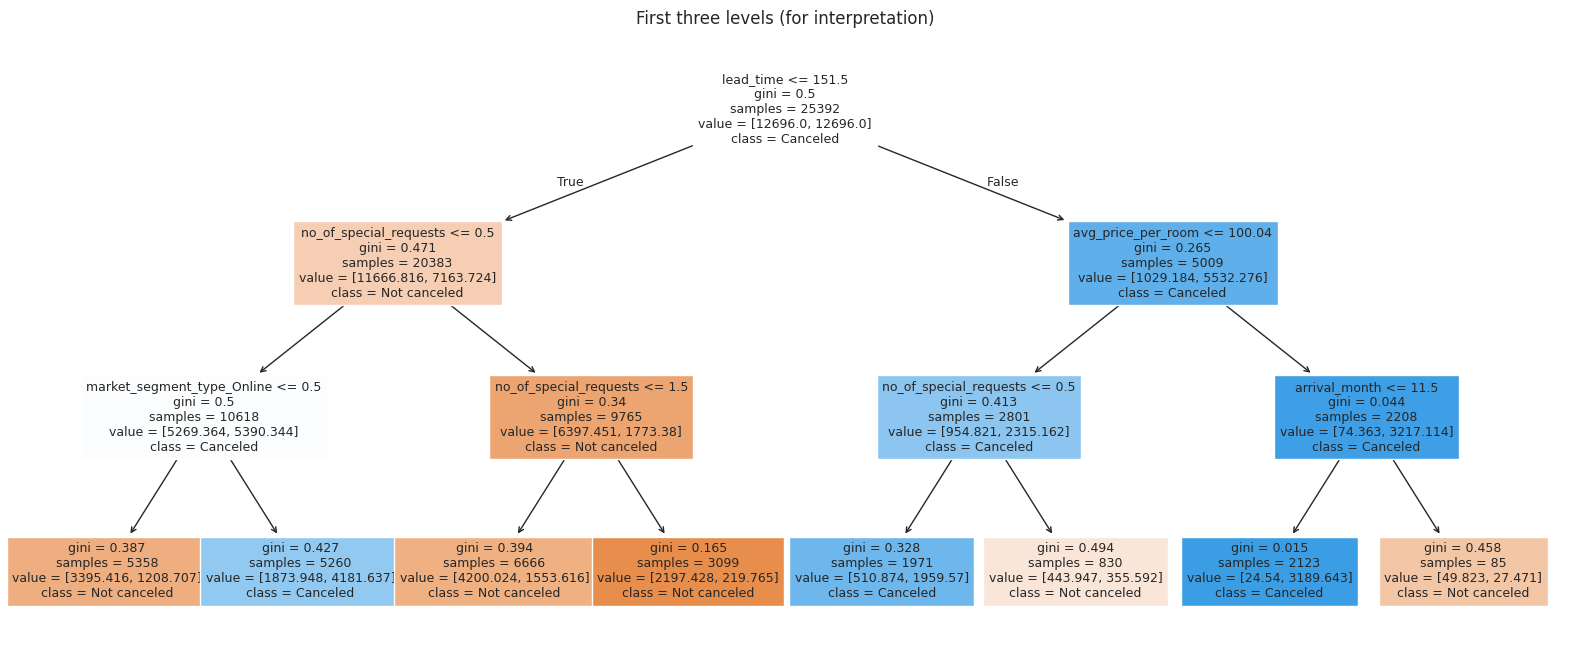

In [21]:
plt.figure(figsize=(20, 8))
plot_tree(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE, class_weight='balanced').fit(X_train, y_train),
          feature_names=X_train.columns, class_names=['Not canceled', 'Canceled'], filled=True, fontsize=9)
plt.title('First three levels (for interpretation)'); plt.show()

## Model performance comparison

In [22]:
comparison = pd.concat([lr_results, dt_results]).sort_values('F1', ascending=False)
comparison

,Accuracy,Recall,Precision,F1,ROC-AUC
Tree (post-pruned),0.860,0.841,0.758,0.798,0.921
Tree (pre-pruned),0.857,0.849,0.748,0.795,0.929
Tree (default),0.863,0.793,0.790,0.791,0.847
LogReg (0.39),0.794,0.715,0.675,0.694,0.861
LogReg (0.50),0.803,0.626,0.733,0.675,0.861


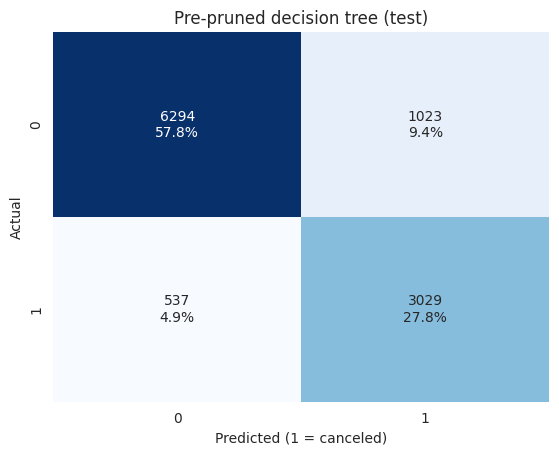

In [23]:
plot_cm(y_test, dt_pre.predict(X_test), 'Pre-pruned decision tree (test)')

## Conclusions
- **Chosen model: the pre-pruned decision tree.** Test F1 0.80, recall 0.85, ROC-AUC 0.93. It catches 85% of cancellations. Train F1 (0.83) is close to test F1, so it does not overfit, and its settings were chosen by cross-validation, not on the test set.
- The post-pruned tree scores about the same, but its alpha was picked on the test set and it has 512 leaves, so it is neither more honest nor simpler.
- The default tree overfits (train F1 0.99 vs test 0.79).
- **Logistic regression** is weaker (F1 0.69 at a 0.39 threshold, ROC-AUC 0.86), but its odds ratios explain *why* bookings cancel, which makes it useful for setting policy.
- **Both models agree on the main drivers:** lead time, number of special requests, room price, Online segment, and arrival month.

## Actionable insights and recommendations
1. **Deposit policy by lead time.** Bookings made more than 90 days ahead cancel 45–74% of the time. Require a partial non-refundable deposit, or free cancellation only up to a deadline, for long-lead bookings.
2. **Encourage special requests.** Guests who add requests rarely cancel. Prompt for preferences (room view, meal, airport pickup) during and after booking.
3. **Targeted overbooking.** Use the model's cancellation probability per booking to set safe overbooking levels for each night, focused on high-probability Online bookings.
4. **Online-channel policy.** Online bookings cancel most (≈37%) and pay the highest prices. Offer a cheaper non-refundable Online rate.
5. **Loyalty.** Repeat guests cancel only 1.7%. Grow the repeat base with a loyalty programme and direct-booking perks.
6. **Reminders.** Send automated reminders and confirmations as arrival approaches. Contact high-risk bookings 2–3 weeks before arrival to confirm or release the room early, while it can still be resold.

**Limitations:** no information on why guests cancel or on their price alternatives. Only two years of data (2017–2018).